Вопросы:

Какие персонажи составляют топ-5 по количеству реплик?


Кто с кем разговаривает и с какой частотой? (используйте heatmap)


Какая локация - самая популярная? (где чаще всего происходят действия)


Какие штаты США упоминаются в сериале, и с какой частотой?


Какие эпизоды самые просматриваемые, и у каких самый высокий
рейтинг imdb?

Как коррелируют количество просмотров и рейтинг?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
charactersData=pd.read_csv('/content/simpsons_characters.csv')
episodesData=pd.read_csv('/content/simpsons_episodes.csv')
locationsData=pd.read_csv('/content/simpsons_locations.csv')
scriptData= pd.read_csv('/content/simpsons_script_lines.csv', on_bad_lines = "skip").sort_values(['episode_id', 'timestamp_in_ms']).reset_index()

<ipython-input-2-ef45199e97c0>:4: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  scriptData= pd.read_csv('/content/simpsons_script_lines.csv', on_bad_lines = "skip").sort_values(['episode_id', 'timestamp_in_ms']).reset_index()


#Топ 5 по количеству реплик

In [ ]:
scriptData

,index,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,148751,4,1,3,Homer Simpson: There's no time to be careful.,10000,true,2,2.0,Homer Simpson,Car,There's no time to be careful.,theres no time to be careful,6.0
1,148752,5,1,4,Homer Simpson: We're late.,10000,true,2,2.0,Homer Simpson,Car,We're late.,were late,2.0
2,149014,263,1,262,Homer Simpson: Who's Tiny Tim?,1001000,true,2,19.0,Homer Simpson,PERSONNEL OFFICE,Who's Tiny Tim?,whos tiny tim,3.0
3,149015,264,1,263,(Simpson Home: int. simpson house - night),1006000,false,NaN,5.0,NaN,Simpson Home,NaN,NaN,NaN
4,149016,265,1,264,"Bubbles: (FROM TV) Hey, Moldy, do you think Sa...",1006000,true,29,5.0,Bubbles,Simpson Home,"Hey, Moldy, do you think Santa will be able to...",hey moldy do you think santa will be able to f...,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158243,147721,158262,568,152,"Helen Lovejoy: (CALLING, SEDUCTIVE) Oh, Asphod...",978000,true,309,843.0,Helen Lovejoy,LOVEJOY HOUSE,"Oh, Asphodel...",oh asphodel,2.0
158244,147722,158263,568,153,Helen Lovejoy: Your corpse bride is getting cold!,983000,true,309,843.0,Helen Lovejoy,LOVEJOY HOUSE,Your corpse bride is getting cold!,your corpse bride is getting cold,6.0
158245,147723,158264,568,154,"Rev. Timothy Lovejoy: (CALLING) Uh, one second...",986000,true,140,843.0,Rev. Timothy Lovejoy,LOVEJOY HOUSE,"Uh, one second, Belladonna! Helen and I have f...",uh one second belladonna helen and i have foun...,18.0
158246,147724,158265,568,155,Helen Lovejoy: Was that a woman's voice? (SEDU...,992000,true,309,843.0,Helen Lovejoy,LOVEJOY HOUSE,Was that a woman's voice? Send her in!,was that a womans voice send her in,8.0


In [ ]:
def createChartForTop(showAll):
  topCahracters=scriptData["raw_character_text"].value_counts().index.tolist()[:5]
  charactersNumber=scriptData["raw_character_text"].value_counts().tolist()[:5]

  if (showAll):
    remaining=scriptData.size-(charactersNumber[0]+charactersNumber[1]+charactersNumber[2]+charactersNumber[3]+charactersNumber[4])
    topCahracters.append("Others")
    charactersNumber.append(remaining)

  fig, ax = plt.subplots()
  ax.pie(charactersNumber, labels=topCahracters)


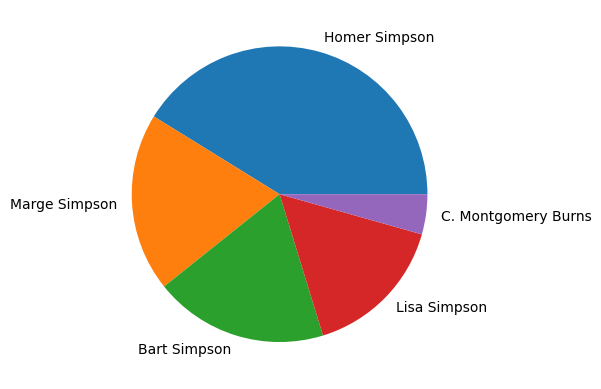

In [ ]:
createChartForTop(False)

#**Кто с кем разговаривает и с какой частотой? (используйте heatmap)**

In [ ]:
def show_whoSpeaks(charNumber):
  data = pd.read_csv('/content/simpsons_script_lines.csv', on_bad_lines = "skip").sort_values(['episode_id', 'timestamp_in_ms']).reset_index().sort_values(['episode_id', 'timestamp_in_ms'])
  cts = data.raw_character_text.value_counts()
  top = list(cts[:charNumber].index)

  # filter top characters
  filtered = data[np.where(data.raw_character_text.isin(top), True, False)]

  # create new dataframe
  d = {'x1' : filtered.raw_character_text[:-1].values,'x2' : filtered.raw_character_text[1:].values}
  df2 = pd.DataFrame.from_dict(d)

  # filter out characters talking to themselves
  df3 = df2[np.where(df2.x1 != df2.x2, True, False)]

<ipython-input-10-73cc232c1003>:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/simpsons_script_lines.csv', on_bad_lines = "skip").sort_values(['episode_id', 'timestamp_in_ms']).reset_index().sort_values(['episode_id', 'timestamp_in_ms'])


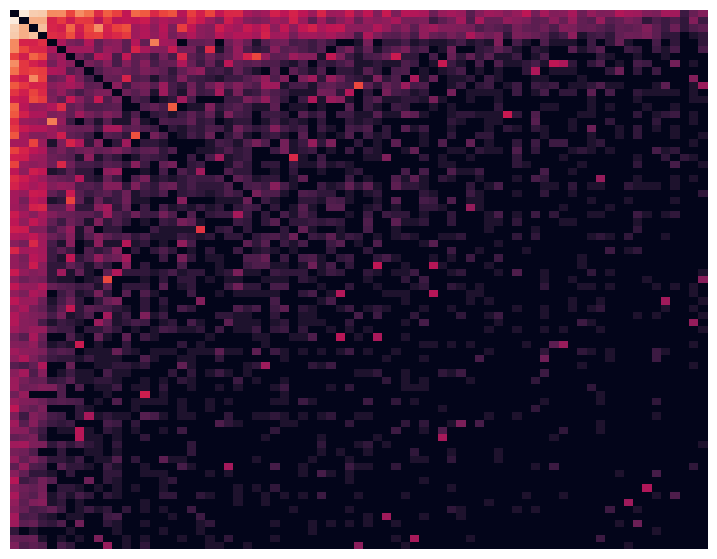

In [ ]:





# create character by character df
df4 = pd.get_dummies(df3.x2).groupby(df3.x1).apply(sum)
df4.columns = list(df4.index)
df4.index = list(df4.index)

# create ordered df
# order = ['Homer Simpson', 'Marge Simpson', 'Bart Simpson', 'Lisa Simpson', 'Grampa Simpson',\
#          'Ned Flanders', 'Seymour Skinner', 'C. Montgomery Burns', 'Moe Szyslak', 'Milhouse Van Houten']

order = top

df6 = df4.loc[order,order]

# scale values
df7 = (df6+1)**(1/4096)

# create plot
fig = plt.figure(figsize=(9,7))
# sns.heatmap(df7, annot=False, cbar_kws={'ticks' : [],
#                                         'extend' : 'max'})
sns.heatmap(df7, annot=False, cbar=False)

plt.xticks([])
plt.yticks([])

# plt.xticks(fontsize = 18, rotation='90')
# plt.yticks(fontsize = 18, rotation='0')
# plt.title(f'The Simpsons: Who speaks to whom?',
#           fontdict={'fontsize': 24},
#           pad=24)
# plt.xlabel(f'\n*Note: rows speak to columns', fontsize=22)
plt.show()

In [ ]:
df1

#**Какая локация - самая популярная? (где чаще всего происходят действия)**

In [ ]:
locationsData.columns

Index(['id', 'name', 'normalized_name'], dtype='object')

In [ ]:
scriptData.raw_location_text.value_counts()

raw_location_text
Simpson Home                        35056
Springfield Elementary School        7092
Moe's Tavern                         4626
Springfield Nuclear Power Plant      3593
Kwik-E-Mart                          1476
                                    ...  
GIRDLES 'N' SUCH, FANCY LINGERIE        1
PSYCHIATRIC CENTER                      1
UNDERGROUND CROSS-SECTION               1
Dilapidated Hotel                       1
Two Guys from Kabul                     1
Name: count, Length: 4497, dtype: int64

In [ ]:
def showLocations(number):
  locName=scriptData["raw_location_text"].value_counts().index.tolist()[:number]
  locNumber=scriptData["raw_location_text"].value_counts().tolist()[:number]

  fig = plt.figure(figsize = (15, 10))

  # creating the bar plot
  plt.bar(locName, locNumber, color ='maroon',
          width = 0.4)

  plt.xlabel("Локации")
  plt.ylabel("Номер появлений ")
  plt.title("Частота появления локаций")
  plt.show()

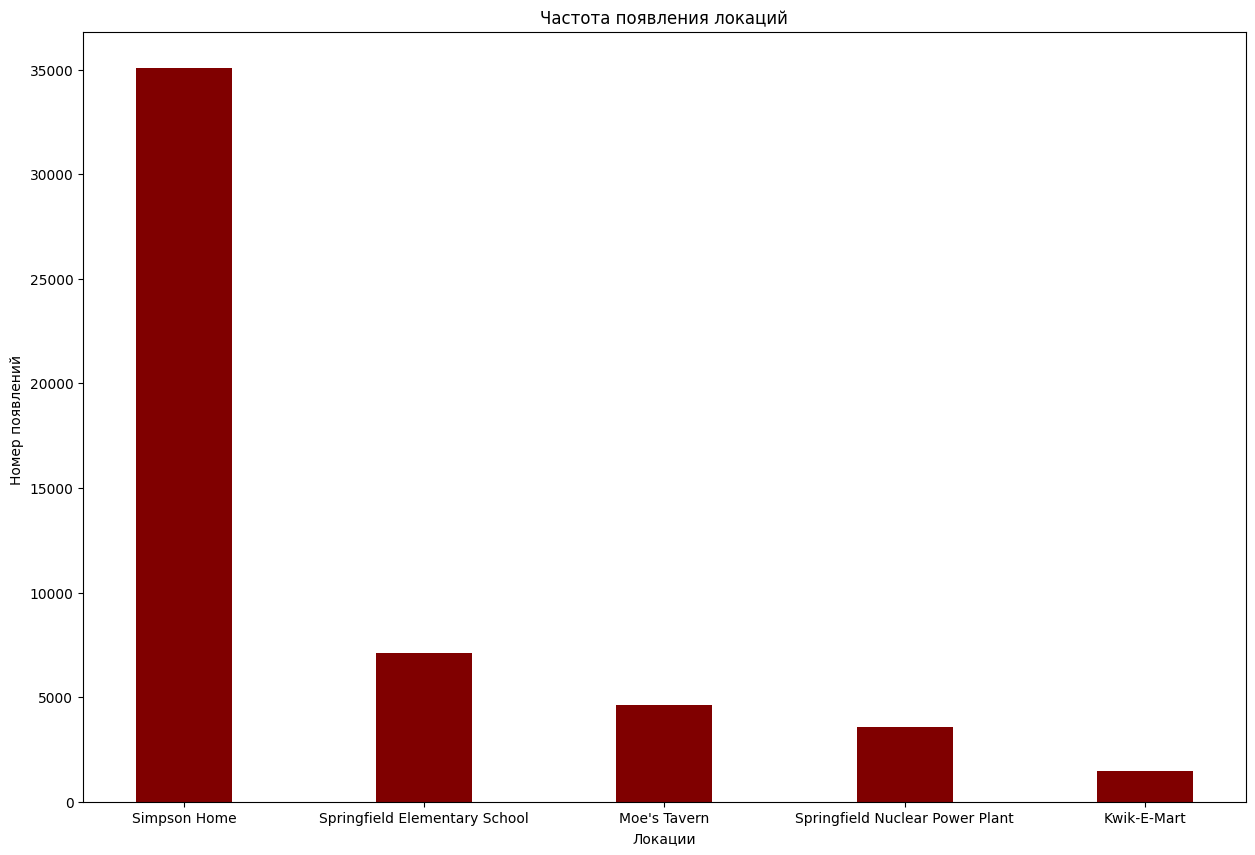

In [ ]:
showLocations(5)

#**Какие штаты США упоминаются в сериале, и с какой частотой?**

Добавить сортировку по значения дикта

In [ ]:
def showStates():

  state_names = ["Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut", "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming"]
  state_names=[x.lower() for x in state_names]
  scriptData[['normalized_text']] = scriptData[['normalized_text']].fillna(value="no text")
  statesMent={}
  for state in state_names:
    count=0
    for index, row in scriptData.iterrows():
      if state in row['normalized_text']:
        count=count+1
    statesMent[state]=count
  statesMent = {key:val for key, val in statesMent.items() if val != 0}

  fig, ax = plt.subplots()
  ax.pie(list(statesMent.values()), labels=list(statesMent.keys()))

<ipython-input-12-69c7f71cf6ec>:2: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  scriptData= pd.read_csv('/content/simpsons_script_lines.csv', on_bad_lines = "skip").sort_values(['episode_id', 'timestamp_in_ms']).reset_index()


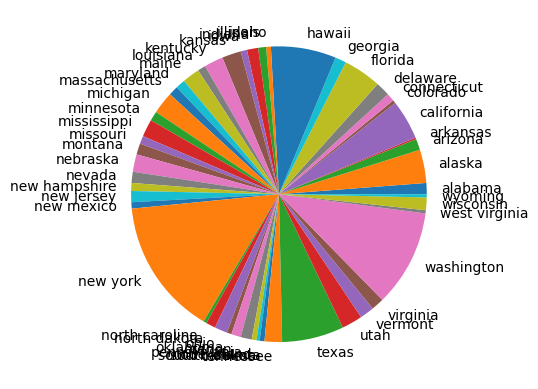

In [ ]:
showStates()
scriptData= pd.read_csv('/content/simpsons_script_lines.csv', on_bad_lines = "skip").sort_values(['episode_id', 'timestamp_in_ms']).reset_index()

#Какие эпизоды самые просматриваемые, и у каких самый высокий рейтинг imdb? Как коррелируют количество просмотров и рейтинг?

Сделать вывод самых популярных эпиходов и по сезону

In [ ]:
popularEpisodes=episodesData.sort_values('views', ascending=False)['title'].tolist()[:5]
popularEpisodesNumbers=episodesData.sort_values('views', ascending=False)['views'].tolist()[:5]

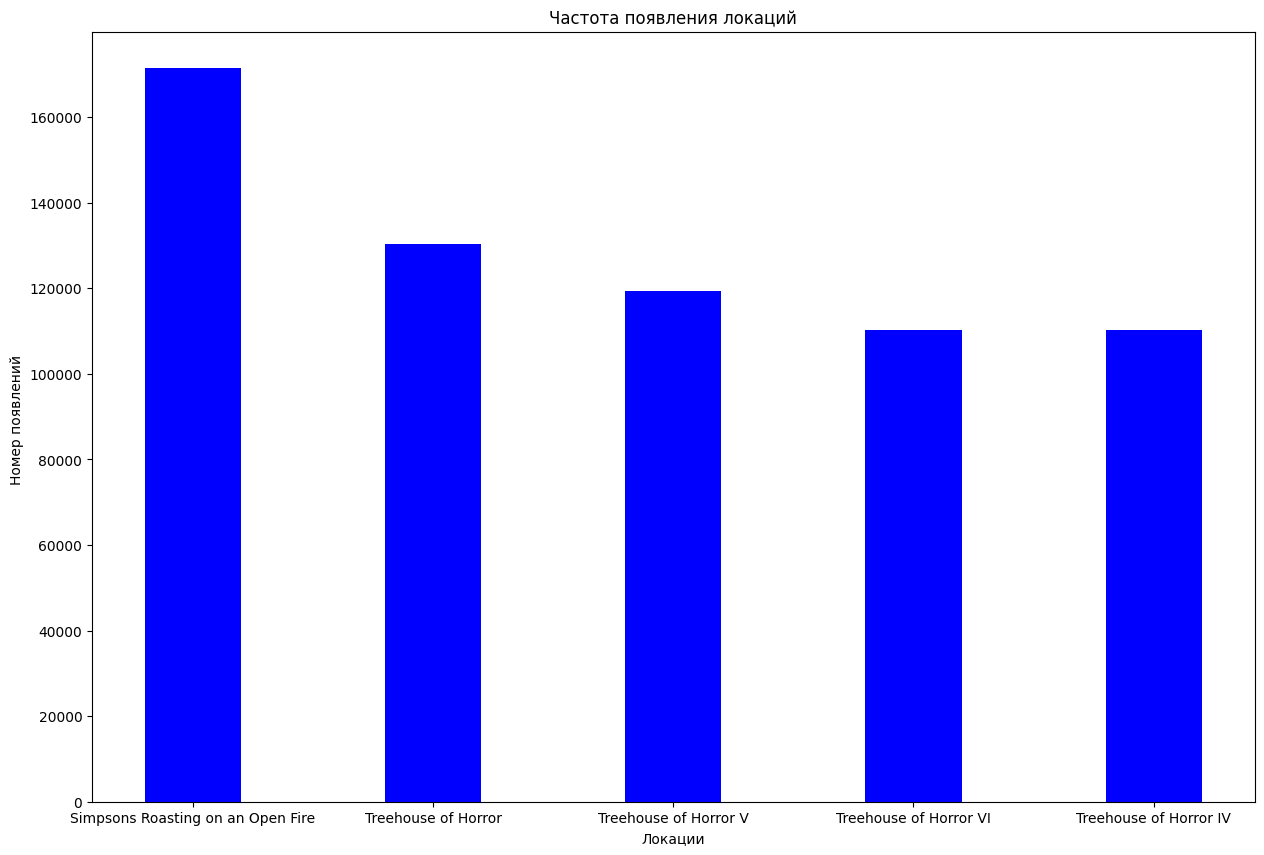

In [ ]:
fig = plt.figure(figsize = (15, 10))

# creating the bar plot
plt.bar(popularEpisodes, popularEpisodesNumbers, color ='blue',
        width = 0.4)

plt.xlabel("Название")
plt.ylabel("Просмотры ")
plt.title("Самые популярные эпизоды")
plt.show()

In [ ]:
bestEpisodes=episodesData.sort_values('imdb_rating', ascending=False)['title'].tolist()[:5]
bestEpisodesNumbers=episodesData.sort_values('imdb_rating', ascending=False)['imdb_rating'].tolist()[:5]

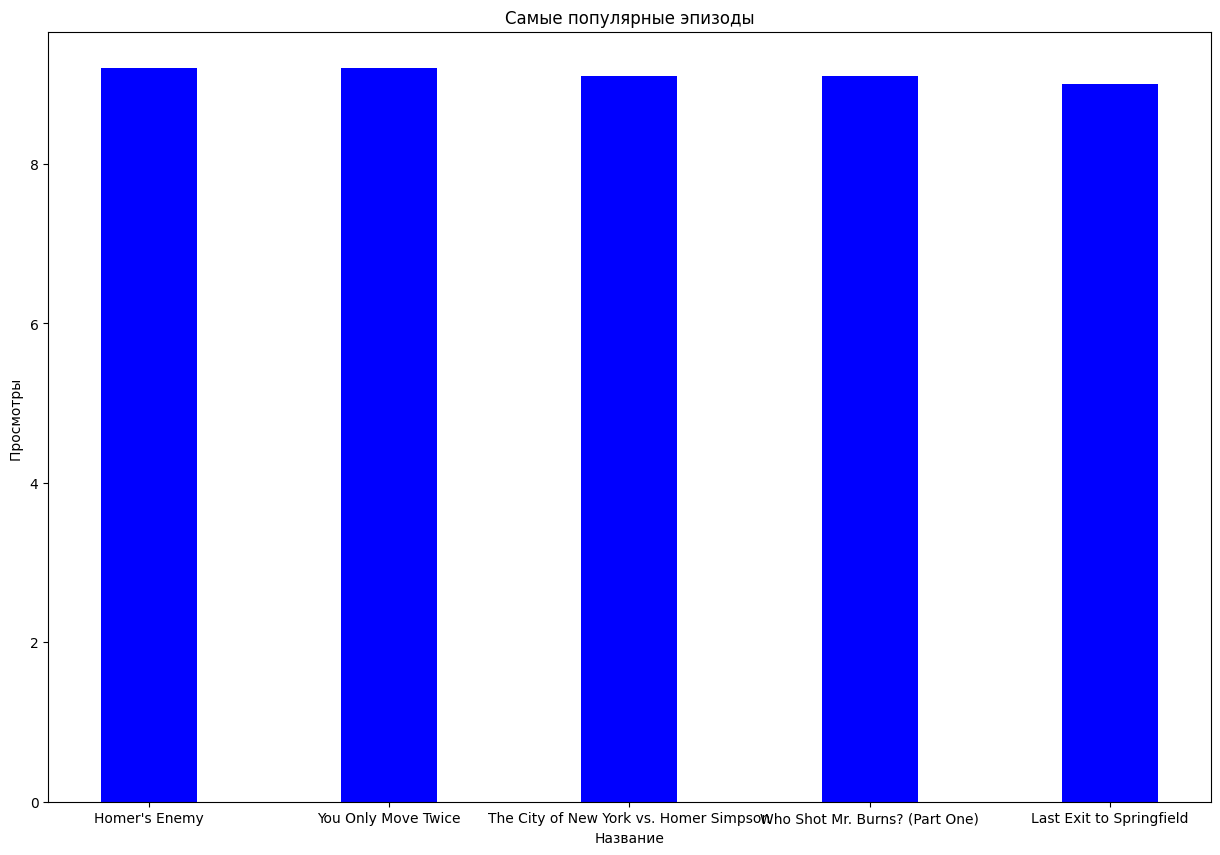

In [ ]:
fig = plt.figure(figsize = (15, 10))

# creating the bar plot
plt.bar(bestEpisodes, bestEpisodesNumbers, color ='blue',
        width = 0.4)

plt.xlabel("Название")
plt.ylabel("Просмотры ")
plt.title("Самые популярные эпизоды")
plt.show()

In [ ]:
episodesData

,id,title,original_air_date,production_code,season,number_in_season,number_in_series,us_viewers_in_millions,views,imdb_rating,imdb_votes,image_url,video_url
0,10,Homer's Night Out,1990-03-25,7G10,1,10,10,30.30,50816.0,7.4,1511.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/275197507879
1,12,Krusty Gets Busted,1990-04-29,7G12,1,12,12,30.40,62561.0,8.3,1716.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/288019523914
2,14,"Bart Gets an ""F""",1990-10-11,7F03,2,1,14,33.60,59575.0,8.2,1638.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/260539459671
3,17,Two Cars in Every Garage and Three Eyes on Eve...,1990-11-01,7F01,2,4,17,26.10,64959.0,8.1,1457.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/260537411822
4,19,Dead Putting Society,1990-11-15,7F08,2,6,19,25.40,50691.0,8.0,1366.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/260539459670
...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,500,At Long Last Leave,2012-02-19,PABF07,23,14,500,5.77,45226.0,7.0,580.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/230541891832
596,502,How I Wet Your Mother,2012-03-11,PABF08,23,16,502,4.97,44818.0,7.3,541.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/230597187582
597,511,Adventures in Baby-Getting,2012-11-04,PABF18,24,3,511,5.65,39687.0,6.9,460.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/221688899646
598,542,Diggs,2014-03-09,SABF08,25,12,542,2.69,39292.0,6.4,473.0,http://static-media.fxx.com/img/FX_Networks_-_...,http://www.simpsonsworld.com/video/310529091639


In [ ]:

corr = episodesData['imdb_rating'].corr(episodesData["views"])

In [ ]:
corr

0.5755122048821844